Vorgehensweise: 

1) Daten laden
2) Daten überprüfen und ggf. bereinigen

3) Datenanalyse und Visualisierungen für das jeweilige Kapitel


1) Daten laden

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [159]:
# Datei aus Unterordner laden
df = pd.read_csv("data/data_in_use/diabetes_binary_health_indicators_BRFSS2015.csv")

# Erste 5 Zeilen anzeigen
df.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


2) Daten überprüfen und ggf. bereinigen

In [160]:
# Anzahl der Datensaätze und Spalten
df.shape

(253680, 22)

In [172]:
# Zeigt Spaltennamen, Anzahl Werte und Datentyp an
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Diabetes_Status          253680 non-null  float64
 1   Bluthochdruck            253680 non-null  float64
 2   Cholesterin_hoch         253680 non-null  float64
 3   Cholesterin_Check        253680 non-null  float64
 4   BMI                      253680 non-null  float64
 5   Raucher_Status           253680 non-null  float64
 6   Schlaganfall             253680 non-null  float64
 7   Herzerkrankung_Infarkt   253680 non-null  float64
 8   Sportliche_Aktivitaet    253680 non-null  float64
 9   Obst_Konsum              253680 non-null  float64
 10  Gemuese_Konsum           253680 non-null  float64
 11  Hoher_Alkoholkonsum      253680 non-null  float64
 12  Krankenversicherung      253680 non-null  float64
 13  Kein_Arzt_wegen_Kosten   253680 non-null  float64
 14  Allgemeine_Gesu

In [ ]:
import pandas as pd

#Spaltennamen auf deutsch übersetzen
# Dictionary für die Übersetzung
uebersetzung = {
    "Diabetes_binary": "Diabetes_Status",
    "HighBP": "Bluthochdruck",
    "HighChol": "Cholesterin_hoch",
    "CholCheck": "Cholesterin_Check",
    "BMI": "BMI",
    "Smoker": "Raucher_Status",
    "Stroke": "Schlaganfall",
    "HeartDiseaseorAttack": "Herzerkrankung_Infarkt",
    "PhysActivity": "Sportliche_Aktivitaet",
    "Fruits": "Obst_Konsum",
    "Veggies": "Gemuese_Konsum",
    "HvyAlcoholConsump": "Hoher_Alkoholkonsum",
    "AnyHealthcare": "Krankenversicherung",
    "NoDocbcCost": "Kein_Arzt_wegen_Kosten",
    "GenHlth": "Allgemeine_Gesundheit",
    "MentHlth": "Psychische_Gesundheit",
    "PhysHlth": "Koerperliche_Gesundheit",
    "DiffWalk": "Einschränkung_Gehen",
    "Sex": "Geschlecht",
    "Age": "Altersgruppe",
    "Education": "Bildungsstand",
    "Income": "Einkommensstufe",
    "BMI_Kategorie_Text": "BMI_Kategorie_Text", 
}

# Spalten im DF umbenennen
df = df.rename(columns=uebersetzung)

# Check
print(df.columns.tolist())

['Diabetes_Status', 'Bluthochdruck', 'Cholesterin_hoch', 'Cholesterin_Check', 'BMI', 'Raucher_Status', 'Schlaganfall', 'Herzerkrankung_Infarkt', 'Sportliche_Aktivitaet', 'Obst_Konsum', 'Gemuese_Konsum', 'Hoher_Alkoholkonsum', 'Krankenversicherung', 'Kein_Arzt_wegen_Kosten', 'Allgemeine_Gesundheit', 'Psychische_Gesundheit', 'Koerperliche_Gesundheit', 'Einschränkung_Gehen', 'Geschlecht', 'Altersgruppe', 'Bildungsstand', 'Einkommensstufe', 'BMI_Kategorie_Text']


In [303]:
# Liste der float64 Spalten die in int8 umgewandelt werden sollen
int8_spalten = [
    "Diabetes_Status",
    "Bluthochdruck",
    "Cholesterin_hoch",
    "Cholesterin_Check",
    "BMI",  
    "Raucher_Status",
    "Schlaganfall",
    "Herzerkrankung_Infarkt",
    "Sportliche_Aktivitaet",
    "Obst_Konsum",
    "Gemuese_Konsum",
    "Hoher_Alkoholkonsum",
    "Krankenversicherung",
    "Kein_Arzt_wegen_Kosten",
    "Allgemeine_Gesundheit",
    "Psychische_Gesundheit",
    "Koerperliche_Gesundheit",
    "Einschränkung_Gehen",
    "Geschlecht",
    "Altersgruppe",
    "Bildungsstand",
    "Einkommensstufe"
]

# Alle aufgelisteten Spalten in int8 konvertieren
df[int8_spalten] = df[int8_spalten].astype("int8")

In [317]:
df.info()

# 8-Werte-Übersicht pro Spalte
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Status          253680 non-null  int8 
 1   Bluthochdruck            253680 non-null  int8 
 2   Cholesterin_hoch         253680 non-null  int8 
 3   Cholesterin_Check        253680 non-null  int8 
 4   BMI                      253680 non-null  int8 
 5   Raucher_Status           253680 non-null  int8 
 6   Schlaganfall             253680 non-null  int8 
 7   Herzerkrankung_Infarkt   253680 non-null  int8 
 8   Sportliche_Aktivitaet    253680 non-null  int8 
 9   Obst_Konsum              253680 non-null  int8 
 10  Gemuese_Konsum           253680 non-null  int8 
 11  Hoher_Alkoholkonsum      253680 non-null  int8 
 12  Krankenversicherung      253680 non-null  int8 
 13  Kein_Arzt_wegen_Kosten   253680 non-null  int8 
 14  Allgemeine_Gesundheit    253680 non-null  int8 

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Kein_Arzt_wegen_Kosten,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Code
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,2.239597
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,1.134719
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,1.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,2.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,3.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,5.000000


In [330]:
# Check doppelte Werte 
df.duplicated().sum()

np.int64(24206)

In [ ]:
 # Zeigt alle Zeilen an, die im Datensatz mehrfach vorkommen
df_duplicates = df[df.duplicated(keep=False)]
df_duplicates

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Text,BMI_Kategorie_Code
5,0,1,1,1,25,1,0,0,1,1,...,2,0,2,0,1,10,6,8,Übergewicht (25.0 - 29.9),2
25,0,0,0,1,32,0,0,0,1,1,...,2,0,0,0,0,5,6,8,Adipositas Grad I (30.0 - 34.9),3
29,0,0,1,1,31,1,0,0,1,1,...,1,0,0,0,1,12,6,8,Adipositas Grad I (30.0 - 34.9),3
44,0,0,1,1,31,1,0,0,0,1,...,2,0,0,0,0,8,5,8,Adipositas Grad I (30.0 - 34.9),3
52,1,1,1,1,27,1,0,0,0,0,...,5,0,30,1,0,10,4,5,Übergewicht (25.0 - 29.9),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1,1,1,1,33,0,0,0,1,1,...,3,0,0,0,1,9,6,6,Adipositas Grad I (30.0 - 34.9),3
253550,0,0,0,1,25,0,0,0,1,1,...,1,0,0,0,0,7,6,8,Übergewicht (25.0 - 29.9),2
253563,0,0,1,1,24,1,0,0,1,1,...,2,0,0,0,1,8,6,8,Normalgewicht (18.5 - 24.9),1
253597,0,0,0,1,24,0,0,0,1,1,...,2,0,0,0,0,5,6,8,Normalgewicht (18.5 - 24.9),1


In [ ]:
# Gruppiert alle identischen Zeilen (Profile) und zählt wie oft sie vorkommen
haeufigste_profile = df.value_counts()

# Zeigt die Top 5 der am häufigsten vorkommenden Profile
haeufigste_profile

Diabetes_Status  Bluthochdruck  Cholesterin_hoch  Cholesterin_Check  BMI  Raucher_Status  Schlaganfall  Herzerkrankung_Infarkt  Sportliche_Aktivitaet  Obst_Konsum  Gemuese_Konsum  Hoher_Alkoholkonsum  Krankenversicherung  Kein_Arzt_wegen_Kosten  Allgemeine_Gesundheit  Psychische_Gesundheit  Koerperliche_Gesundheit  Einschränkung_Gehen  Geschlecht  Altersgruppe  Bildungsstand  Einkommensstufe  BMI_Kategorie_Text             BMI_Kategorie_Code
0                0              0                 1                  21   0               0             0                       1                      1            1               0                    1                    0                       1                      0                      0                        0                    0           6             6              8                Normalgewicht (18.5 - 24.9)    1                     59
                                                                     23   0               0           

In [342]:
# Das absolut häufigste Profil ermitteln (Index 0 der sortierten Liste)
haeufigstes_profil_index = df.value_counts().index[0]
haeufigstes_profil_anzahl = df.value_counts().iloc[0]

# Als Tabelle darstellen
df_top_profil = pd.DataFrame([haeufigstes_profil_index], columns=df.columns)

print(f"Dieses Profil kommt exakt {haeufigstes_profil_anzahl} Mal im Datensatz vor:\n")
df_top_profil.T   # .T dreht die Tabelle hochkant

Dieses Profil kommt exakt 59 Mal im Datensatz vor:



,0
Diabetes_Status,0
Bluthochdruck,0
Cholesterin_hoch,0
Cholesterin_Check,1
BMI,21
Raucher_Status,0
Schlaganfall,0
Herzerkrankung_Infarkt,0
Sportliche_Aktivitaet,1
Obst_Konsum,1


Die gleichen Profile resultieren aus der Art der Befragung. Die Antwortmöglichkeiten sind sehr oft Ja/Nein, so dass es bei einer Gesamtdatenmenge von 253.680 Befragten (Profilen) zu Dopplungen kommen kann. Deshalb wurden diese Datensätze nicht gelöscht.

In [343]:
# Check missing values
df_NaN_True = df.isna()   # mit den beiden Zeilen Anzahl der NaN
df_NaN_True.sum()

Diabetes_Status            0
Bluthochdruck              0
Cholesterin_hoch           0
Cholesterin_Check          0
BMI                        0
Raucher_Status             0
Schlaganfall               0
Herzerkrankung_Infarkt     0
Sportliche_Aktivitaet      0
Obst_Konsum                0
Gemuese_Konsum             0
Hoher_Alkoholkonsum        0
Krankenversicherung        0
Kein_Arzt_wegen_Kosten     0
Allgemeine_Gesundheit      0
Psychische_Gesundheit      0
Koerperliche_Gesundheit    0
Einschränkung_Gehen        0
Geschlecht                 0
Altersgruppe               0
Bildungsstand              0
Einkommensstufe            0
BMI_Kategorie_Text         0
BMI_Kategorie_Code         0
dtype: int64

In [358]:
#  Einteilung für BMI-Werte vornehmen
#  neue Spalte erstellen und BMI in aktuelle WHO-Klassifikation einordnenzurdnen

def bmi_kategorie_who(bmi):
    if bmi < 18.5:
        return "Untergewicht (< 18.5)"
    elif bmi < 25.0:
        return "Normalgewicht (18.5 - 24.9)"
    elif bmi < 30.0:
        return "Übergewicht (25.0 - 29.9)"
    elif bmi < 35.0:
        return "Adipositas Grad I (30.0 - 34.9)"
    elif bmi < 40.0:
        return "Adipositas Grad II (35.0 - 39.9)"
    else:
        return "Adipositas Grad III (>= 40.0)"


# Spalte mit den Kategorien überschreiben / anlegen
df["BMI_Kategorie_Text"] = df["BMI"].apply(bmi_kategorie_who)

# korrekte Reihenfolge für spätere Grafiken (z.B. Sortierung auf den Achsen) definieren
reihenfolge_who = [
    "Untergewicht (< 18.5)",
    "Normalgewicht (18.5 - 24.9)",
    "Übergewicht (25.0 - 29.9)",
    "Adipositas Grad I (30.0 - 34.9)",
    "Adipositas Grad II (35.0 - 39.9)",
    "Adipositas Grad III (>= 40.0)",
]

In [365]:
# BMI numerische Spalte für die Heatmap

def bmi_kategorie_code(bmi):
    if bmi < 18.5:
        return 0  # Untergewicht
    elif bmi < 25.0:
        return 1  # Normalgewicht
    elif bmi < 30.0:
        return 2  # Übergewicht
    elif bmi < 35.0:
        return 3  # Adipositas Grad I
    elif bmi < 40.0:
        return 4  # Adipositas Grad II
    else:
        return 5  # Adipositas Grad III

# Neue numerische Spalte 
df["BMI_Kategorie_Code"] = df["BMI"].apply(bmi_kategorie_code)

# Datentyp int8 um
df["BMI_Kategorie_Code"] = df["BMI_Kategorie_Code"].astype("int8")

# Check
print(df[["BMI", "BMI_Kategorie_Text", "BMI_Kategorie_Code"]].head())


   BMI             BMI_Kategorie_Text  BMI_Kategorie_Code
0   40  Adipositas Grad III (>= 40.0)                   5
1   25      Übergewicht (25.0 - 29.9)                   2
2   28      Übergewicht (25.0 - 29.9)                   2
3   27      Übergewicht (25.0 - 29.9)                   2
4   24    Normalgewicht (18.5 - 24.9)                   1


Heatmap: Mit allen numerischen Variablen. Daraus soll sich der Fokus für die Datananylyse ergeben

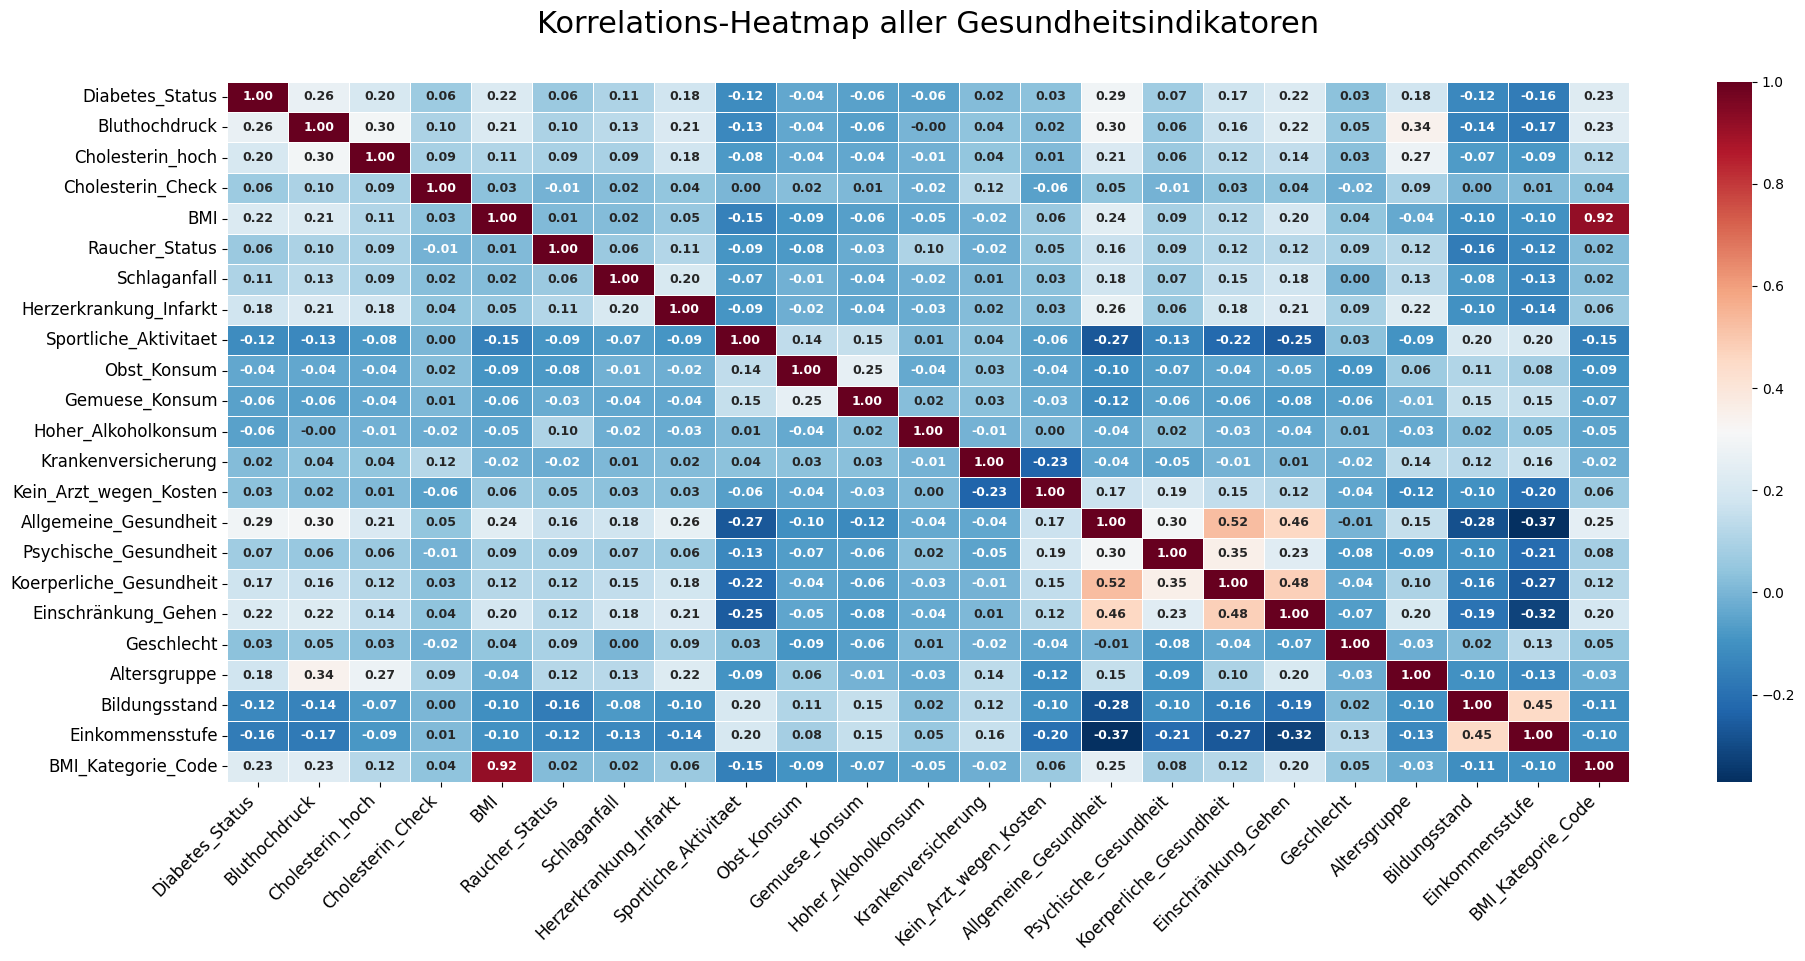

In [366]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# numerischen Spalten auswählen
df_numerisch = df.select_dtypes(include=["number"])

# Korrelationsmatrix berechnen
corr_matrix = df_numerisch.corr()

# Plot in Präsentationsgröße
plt.figure(figsize=(20, 10))

# Heatmap barrierefreier Palette 
sns.heatmap(
    corr_matrix,
    annot=True,             # Schreibt die Werte in die Kästchen
    cmap="RdBu_r",          # barrierefreier Palette 
    fmt=".2f",              # Rundet auf 2 Nachkommastellen
    linewidths=0.5,         # Feine Trennlinien zwischen den Quadraten
    annot_kws={
        "size": 9,
        "weight": "bold",   # Zahlen im Fettdruck
    },  
)

# für PowerPoint-Folie
plt.title(
    "Korrelations-Heatmap aller Gesundheitsindikatoren", fontsize=22, pad=35
)

# Beschriftungen drehen, damit Spaltennamen besser lesbar sind
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Ränder belassen absichern, damit nichts abgeschnitten wird
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.18)

# Optionale Speicherung in hoher Qualität für PowerPoint (Raute bei Bedarf entfernen)
# plt.savefig('korrelations_heatmap_deutsch.png', dpi=300, bbox_inches='tight')

plt.show()


3) Datenanalyse und Visualsierungen

Daten sind strukturell in (X) und (y) aufgeteilt, wie man es für eine logistische Regression vorbereiten würde. 
Der Datensatz bleibt so organisiert, daß im Folgenden statistischen Häufigkeiten zwischen den Gruppen analysiert werden können.

Aus der Heatmap ergeben sich folgende Möglichkeiten zur Untersuchung: Wobei ich sehen möchte ob es einen Unterschied für Geschlechter gibt (den Aspekt werde ich evtl. wieder herausnehmen, wenn es zu aufwändig wird ---- Visualisierungen etc.)

1) wie erwartet der BMI

2) Alter und Demografie
   Bildungsstand / Einkommenstufe

4) Lebensqualität und Folgeerscheinungen
   Frage könnte sein : Wie beeinflusst Diabetes die subjektive Lebensqualität und die mentale Gesundheit?
   Untersuchung der Variablen Allgemeine Gesundheit,  
                              Mentale Gesundheit und 
                              Körperliche Gesundheit. 
    Wieviel schlechter (viele Tage im Monat) fühlen sich Diabetiker im Vergleich zu Gesunden?

5) Bluthochdruck und Cholesterin 



Datenanalyse und Visualisierung 

3.1 nach Geschlecht
3.2 nach BMI

3.1 nach Geschlecht

In [371]:
print(len(df['Geschlecht']))
print(df['Geschlecht'].map({0.0: 'Frauen (0.0)', 1.0: 'Männer (1.0)'}).value_counts())

253680
Geschlecht
Frauen (0.0)    141974
Männer (1.0)    111706
Name: count, dtype: int64


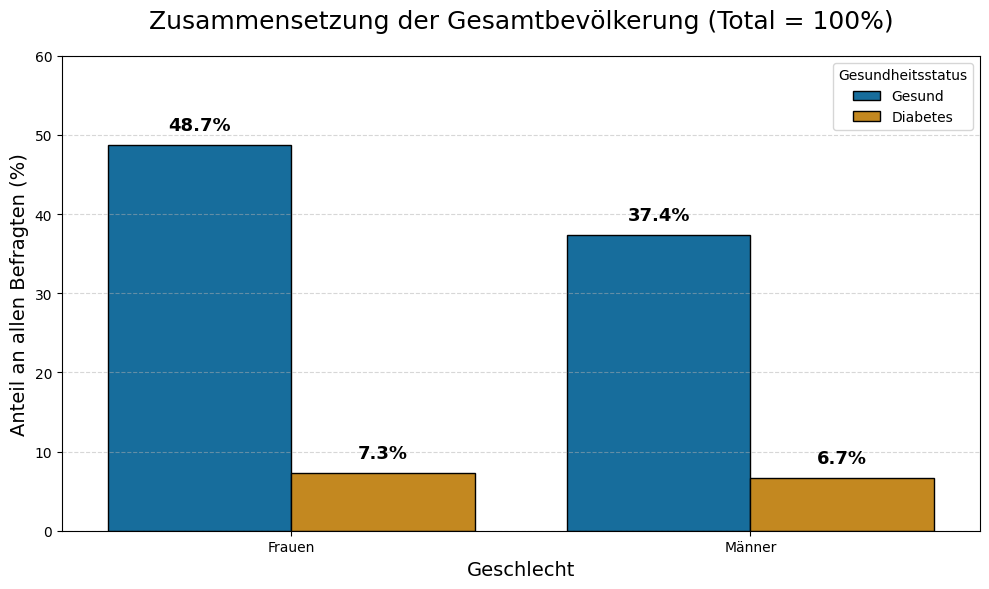

In [372]:
# Zusammensetzung gesamt und nach Geschlecht
import pandas as pd  # <-- Das löst den NameError für 'pd'
import matplotlib.pyplot as plt
import seaborn as sns


# Berechne den prozentualen Anteil jeder Kombination an der GESAMTANZAHL alle Befragten (Total = 100%)
gesamt_aufteilung = (
    pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="all") * 100
)

gesamt_df = gesamt_aufteilung.stack().reset_index()   # Umwandeln in ein für Seaborn lesbares Format
gesamt_df.columns = ["Geschlecht", "Diabetes_Status", "Prozent_an_Gesamtpopulation"]   # aus der Crosstab

# Beschriftungen für die Folie 
gesamt_df["Geschlecht"] = gesamt_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})
gesamt_df["Diabetes_Status"] = gesamt_df["Diabetes_Status"].map(
    {0: "Gesund", 1: "Diabetes"}
)

# Seaborn Plot
plt.figure(figsize=(10, 6))

# Balkendiagramm 
ax = sns.barplot(
    data=gesamt_df,
    x="Geschlecht",
    y="Prozent_an_Gesamtpopulation",
    hue="Diabetes_Status",
    palette="colorblind",  # barrierefreies Farbschema
    edgecolor="black",
)

# Styling PowerPoint-Folie
plt.title(
    "Zusammensetzung der Gesamtbevölkerung (Total = 100%)", fontsize=18, pad=20
)
plt.xlabel("Geschlecht", fontsize=14)
plt.ylabel("Anteil an allen Befragten (%)", fontsize=14)
plt.ylim(0, 60)  # Genug Platz nach oben für die Text-Labels
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Legende anpassen
plt.legend(title="Gesundheitsstatus", loc="upper right")

# Methode, um Prozentzahlen über die Balken zu schreiben
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",  # Formatiert als Fließkommazahl mit Prozentzeichen
        label_type="edge",
        padding=8,  # Eleganter Abstand nach oben ohne Hardcode
        color="black",
        fontweight="bold",
        fontsize=13,
    )

plt.tight_layout()
plt.show()



3.2 nach BMI

In [375]:
print(df[["BMI", "BMI_Kategorie_Text"]].value_counts().sort_index())

df[df["BMI"] >= 40]["BMI"].value_counts()

BMI  BMI_Kategorie_Text           
12   Untergewicht (< 18.5)              6
13   Untergewicht (< 18.5)             21
14   Untergewicht (< 18.5)             41
15   Untergewicht (< 18.5)            132
16   Untergewicht (< 18.5)            348
                                     ... 
91   Adipositas Grad III (>= 40.0)      1
92   Adipositas Grad III (>= 40.0)     32
95   Adipositas Grad III (>= 40.0)     12
96   Adipositas Grad III (>= 40.0)      1
98   Adipositas Grad III (>= 40.0)      7
Name: count, Length: 84, dtype: int64


BMI
40    2258
41    1659
42    1639
43    1500
44    1043
45     819
46     750
47     622
48     484
49     416
50     372
51     253
53     237
52     215
55     169
54     113
56     109
57      86
58      71
79      66
60      63
87      61
77      55
59      54
75      52
81      49
71      49
73      47
84      44
62      43
82      37
61      35
63      34
92      32
89      28
64      24
65      19
74      16
67      15
70      15
68      14
72      14
66      13
95      12
69       9
98       7
76       3
88       2
83       2
80       2
85       1
96       1
91       1
86       1
90       1
78       1
Name: count, dtype: int64

In [ ]:
# Absolute Häufigkeiten berechnen (nutzt die Definitionen von weiter oben im Notebook -> def bmi_kategorie_code)
# print(df["BMI_Kategorie_Code"].head())
# ?bmi_kategorie_code

bmi_counts = df["BMI_Kategorie_Text"].value_counts().reindex(reihenfolge_who)

print("--- 1. Absolute Anzahl Personen im Datensatz ---")
print()
for kat in reihenfolge_who:
    anzahl = bmi_counts[kat]
    print(f"{kat:<32} | Anzahl Personen: {anzahl:,}")
print()

# Reale Diabetes-Rate (in %) innerhalb der Gruppen berechnen
bmi_rates_who = df.groupby("BMI_Kategorie_Text")["Diabetes_Status"].mean() * 100

print("--- 2. Reale Diabetes-Rate innerhalb der Gruppen ---")
print()
for kat in reihenfolge_who:
    rate = bmi_rates_who[kat]
    print(f"{kat:<32} | Diabetes-Rate: {rate:.1f}%")

--- 1. Absolute Anzahl Personen im Datensatz ---

Untergewicht (< 18.5)            | Anzahl Personen: 3,127
Normalgewicht (18.5 - 24.9)      | Anzahl Personen: 68,953
Übergewicht (25.0 - 29.9)        | Anzahl Personen: 93,749
Adipositas Grad I (30.0 - 34.9)  | Anzahl Personen: 53,451
Adipositas Grad II (35.0 - 39.9) | Anzahl Personen: 20,663
Adipositas Grad III (>= 40.0)    | Anzahl Personen: 13,737

--- 2. Reale Diabetes-Rate innerhalb der Gruppen ---

Untergewicht (< 18.5)            | Diabetes-Rate: 5.4%
Normalgewicht (18.5 - 24.9)      | Diabetes-Rate: 5.7%
Übergewicht (25.0 - 29.9)        | Diabetes-Rate: 11.4%
Adipositas Grad I (30.0 - 34.9)  | Diabetes-Rate: 19.2%
Adipositas Grad II (35.0 - 39.9) | Diabetes-Rate: 27.4%
Adipositas Grad III (>= 40.0)    | Diabetes-Rate: 33.5%


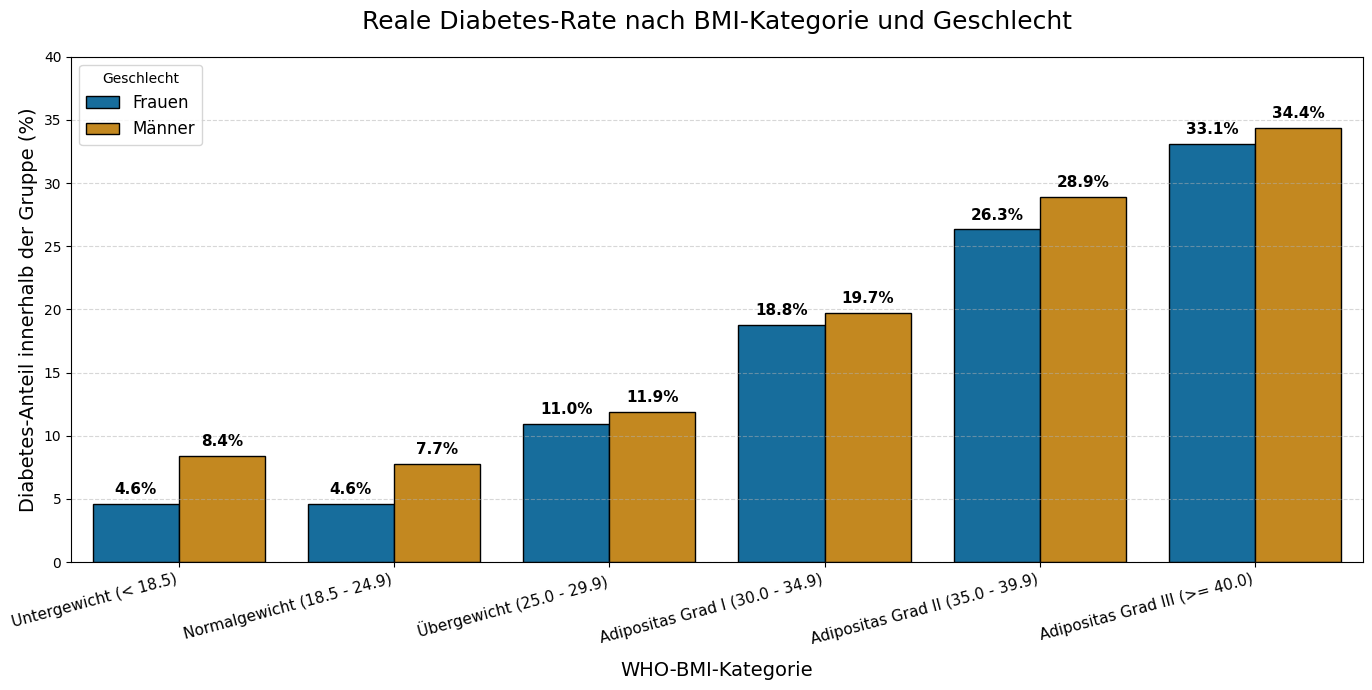

In [383]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Daten aggregieren: Berechnet die Diabetes-Rate (%) nach BMI-Kategorie und Geschlecht
# gruppieren nach beiden Spalten und berechnen den Mittelwert der Zielvariablen Diabetes_Status.
bmi_geschlecht_rates = (
    df.groupby(["BMI_Kategorie_Text", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()       

# numerischen Geschlechter-Codes (0 und 1) für die Grafik übersetzen
bmi_geschlecht_rates["Geschlecht"] = bmi_geschlecht_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# pLOT
plt.figure(figsize=(14, 7))

# Gruppiertes Balkendiagramm erstellen
# 'order=reihenfolge_who' sorgt dafür, dass die BMI-Klassen logisch sortiert auf der Achse liegen.
ax = sns.barplot(
    data=bmi_geschlecht_rates,
    x="BMI_Kategorie_Text",
    y="Diabetes_Status",
    hue="Geschlecht",
    order=reihenfolge_who,  # Nutzt definierte Reihenfolge
    palette="colorblind",   # Barrierefreies Farbschema
    edgecolor="black",
)

# Styling für PowerPoint-Folie
plt.title(
    "Reale Diabetes-Rate nach BMI-Kategorie und Geschlecht", fontsize=18, pad=20
)
plt.xlabel("WHO-BMI-Kategorie", fontsize=14, labelpad=10)
plt.ylabel("Diabetes-Anteil innerhalb der Gruppe (%)", fontsize=14)
plt.ylim(0, 40)  # Genug Platz für die Text-Labels
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Legende positionieren
plt.legend(title="Geschlecht", loc="upper left", fontsize=12)

# Beschriftung der X-Achse ankippen
plt.xticks(rotation=15, ha="right", fontsize=11)

# Prozentzahlen über Balken schreiben
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=5,
        color="black",
        fontweight="bold",
        fontsize=11,
    )

# Layout optimieren und anzeigen
plt.tight_layout()
plt.show()
